In [71]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
# cnn models
class SmallCNN(nn.Module): # a small cnn with 2 conv layers
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))
class MediumCNN(nn.Module): # a medium cnn with 2 conv layers and double the neurons + dropout
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))
class LargeCNN(nn.Module): # a large cnn with 3 conv layers + stricter dropout
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [73]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_size = 50000
val_size = 10000
train_set, val_set = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64)


In [74]:
# training loop
def train_one_run(epochs, model_type, optimizer, loss_fn):
    model = model_type
    optimizer = optimizer
    loss_fn = loss_fn

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # train
        model.train()
        total_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # val
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x)
                loss = loss_fn(out, y)
                val_loss_total += loss.item()
        val_losses.append(val_loss_total / len(val_loader))

    return np.array(train_losses), np.array(val_losses)

In [75]:
# Hyperparameters and different models, loss functions and optimizers
epochs = 5
# learning_rate = 1e-3
learning_rate = 1e-4
# model = SmallCNN()
# model = MediumCNN()
model = LargeCNN()
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

In [76]:
# training setup and losses
num_runs = 5
all_train_losses = []
all_val_losses = []

for run in range(num_runs):
    t_loss, v_loss = train_one_run(epochs= epochs, model_type = model, optimizer = optimizer, loss_fn = loss_fn)
    all_train_losses.append(t_loss)
    all_val_losses.append(v_loss)
    print(f"Finished training run {run + 1}")

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

Finished training run 1
Finished training run 2
Finished training run 3
Finished training run 4
Finished training run 5


In [77]:
# dataframe builder for plotting
def build_df(loss_array):
    runs, epochs = loss_array.shape
    df = pd.DataFrame({
        "epoch": np.tile(np.arange(1, epochs + 1), runs),
        "loss": loss_array.flatten(),
        "run": np.repeat(np.arange(1, runs + 1), epochs)
    })
    return df


train_df = build_df(all_train_losses)
val_df = build_df(all_val_losses)

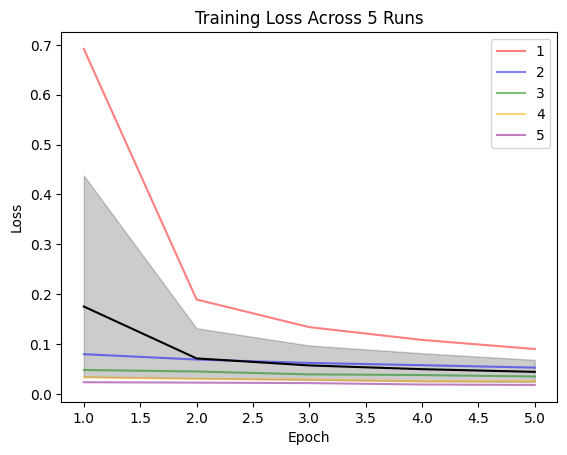

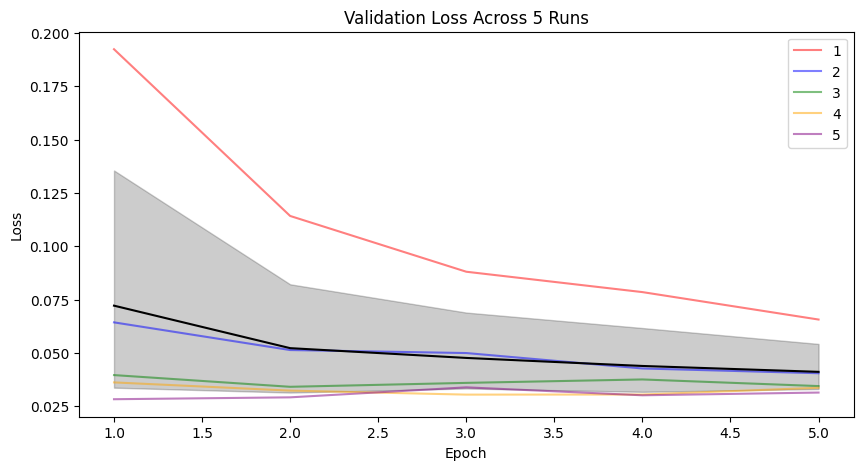

In [78]:
# graphs
colors = ["red", "blue", "green", "orange", "purple"]

sns.lineplot( data=train_df, x="epoch", y="loss", hue="run", estimator=None, alpha=0.5, palette=colors)
# mean plot and 95% confidence interval
sns.lineplot( data=train_df, x="epoch", y="loss", color="black", errorbar=("ci", 95)) # mean line in black
plt.title("Training Loss Across 5 Runs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# val graphs
plt.figure(figsize=(10, 5))
sns.lineplot( data=val_df, x="epoch", y="loss", hue="run", estimator=None, alpha=0.5, palette=colors)
# same as before for val
sns.lineplot( data=val_df, x="epoch", y="loss", color="black", errorbar=("ci", 95)) # mean line in black

plt.title("Validation Loss Across 5 Runs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()